# Day 2: Dimensionality Reduction with PCA

<a target="_blank" href="https://colab.research.google.com/github/LuWidme/uk259/blob/main/demos/05_Dimensionality_Reduction.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## What is Dimensionality Reduction?

**Simple explanation:** Dimensionality reduction is like taking a photo of a 3D object. You go from 3 dimensions to 2 dimensions, but you still capture most of the important information.

### The Problem: Too Many Features!

Imagine you have data about customers with 50 different features:
- Age, income, spending habits, browsing history, location data...
- That's 50 dimensions!
- Impossible to visualize
- Slow to process
- Hard to understand

**What if many of these features are related?**
- Age and "years until retirement" → basically the same thing
- "Number of purchases" and "total spending" → highly correlated
- We're wasting computational power on redundant information!

### The Solution: Dimensionality Reduction

**Goal:** Reduce 50 features → 2 or 3 features while keeping the most important patterns.

**Benefits:**
- ✓ **Visualize your data** - Plot in 2D or 3D
- ✓ **Faster training** - Fewer features = faster algorithms
- ✓ **Less storage** - Smaller datasets
- ✓ **Remove noise** - Filter out irrelevant variations
- ✓ **Avoid overfitting** - Simpler models generalize better

---

## What is PCA?

**PCA (Principal Component Analysis)** is the most popular dimensionality reduction technique.

### How PCA Works (Simple Explanation)

Think of your data as a cloud of points in space:

1. **Find the direction where data varies the most** → This becomes Principal Component 1 (PC1)
2. **Find the next best direction (perpendicular to PC1)** → This is PC2
3. **Continue for PC3, PC4, etc.**
4. **Keep only the top components** → Reduce dimensions!

**Real-world analogy:**

Imagine measuring the size of rectangles:
- You measure width AND diagonal AND area AND perimeter...
- But really, you only need **length** and **width** (2 dimensions)
- Everything else can be calculated from those two!
- PCA finds those fundamental "length and width" dimensions automatically

### When to Use PCA?

**✓ Good use cases:**
- Visualizing high-dimensional data (10+ features)
- Speeding up machine learning algorithms
- Reducing storage requirements
- Removing correlated features
- Image compression
- Face recognition ("Eigenfaces")

**✗ When NOT to use PCA:**
- Your features are already independent
- You need to interpret individual features (PCA creates new features)
- You have categorical data (PCA works on numbers)
- Non-linear patterns (use t-SNE or UMAP instead)

---

## Setup

Let's import the necessary libraries:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn import datasets

# Set style
sns.set_style('whitegrid')
%matplotlib inline

# For reproducibility
np.random.seed(42)

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


---

## Part 1: The Challenge - Visualizing 4D Data

Let's load the famous **Iris dataset** with 4 features:
1. Sepal length
2. Sepal width  
3. Petal length
4. Petal width

**Problem:** How do we visualize 4 dimensions?

In [2]:
# Load Iris dataset
iris = datasets.load_iris(as_frame=True)
X = iris.data  # 4 features
y = iris.target  # 3 species
target_names = iris.target_names

print("Dataset shape:", X.shape)
print("Features:", iris.feature_names)
print("\nFirst 5 rows:")
print(X.head())

print("\nChallenge: We have 4 features but can only plot in 2D or 3D!")

Dataset shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Challenge: We have 4 features but can only plot in 2D or 3D!


### Current Approach: Pairplot

One way is to look at all possible pairs of features:

<Figure size 1200x1000 with 0 Axes>

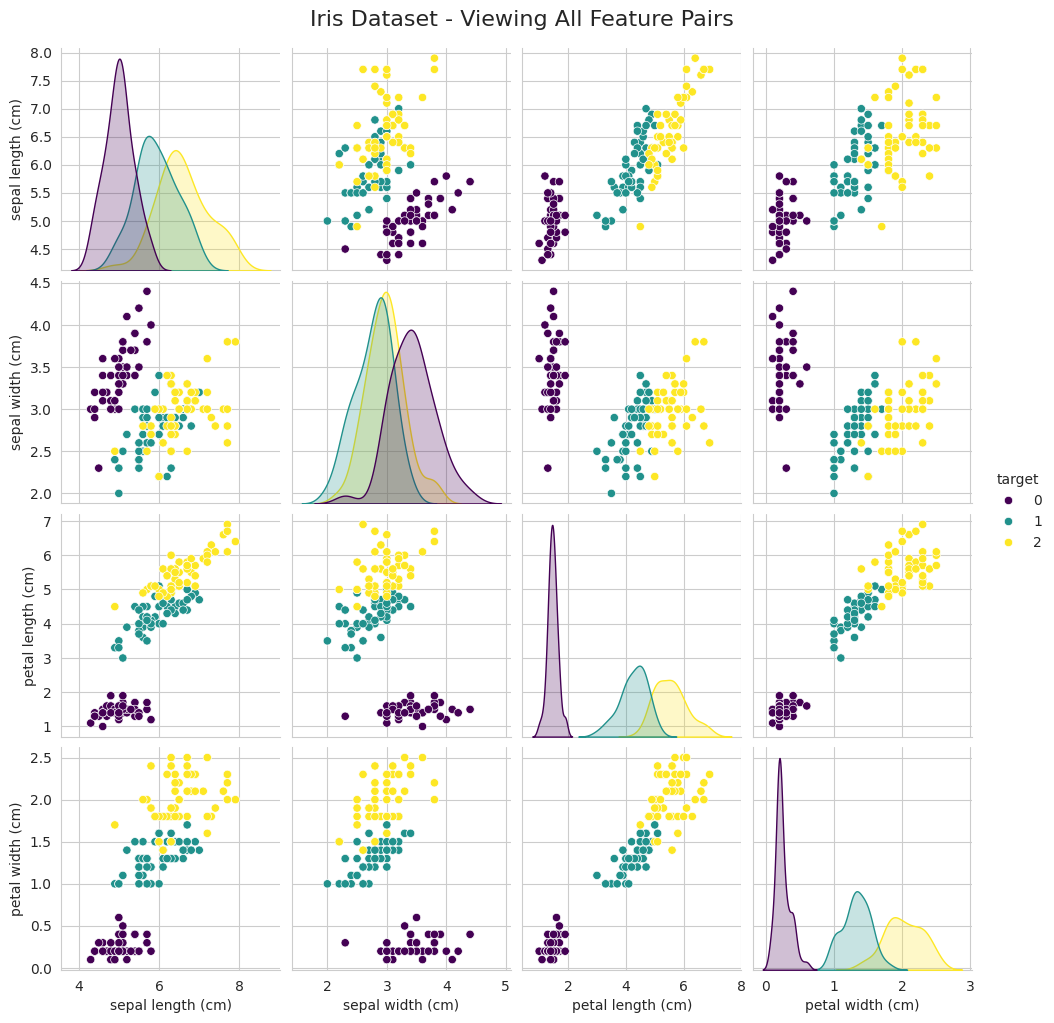

In [3]:
# Create pairplot
plt.figure(figsize=(12, 10))
sns.pairplot(iris.frame, hue='target', palette='viridis', height=2.5)
plt.suptitle('Iris Dataset - Viewing All Feature Pairs', y=1.02, fontsize=16)
plt.show()


Problem: That's a lot of plots to look at!
With 4 features, we need 6 different 2D views.
With 50 features, we'd need 1,225 plots!

*Solution*: Use PCA to reduce to just 2 dimensions!

### Approach 2: 3D Plot with 4th Dimension as Color

We can use 3 axes for the first 3 features and color for the 4th:

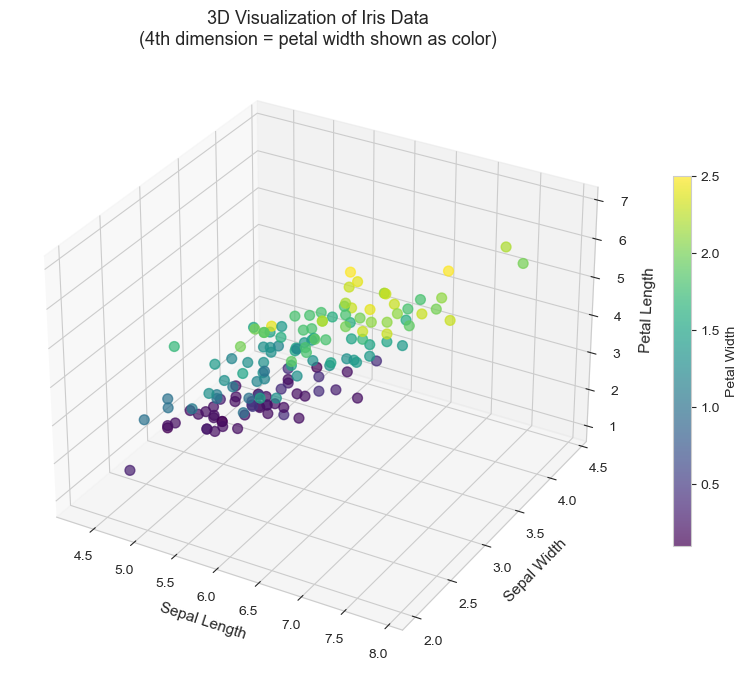

In [19]:
# Create 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Use first 3 features for axes, 4th for color
scatter = ax.scatter(
    X.iloc[:, 0],  # sepal length
    X.iloc[:, 1],  # sepal width
    X.iloc[:, 2],  # petal length
    c=X.iloc[:, 3],  # petal width (as color)
    cmap='viridis',
    s=50,
    alpha=0.7
)

ax.set_xlabel('Sepal Length', fontsize=11)
ax.set_ylabel('Sepal Width', fontsize=11)
ax.set_zlabel('Petal Length', fontsize=11)
ax.set_title('3D Visualization of Iris Data\n(4th dimension = petal width shown as color)',
             fontsize=13)
plt.colorbar(scatter, label='Petal Width', ax=ax, shrink=0.6)
plt.show()


This works for 4D, but what about 10D? 50D? 1000D?
We need a better solution: Dimensionality Reduction!



---

## Part 2: Using PCA with Sklearn

### Step 1: Standardize the Data

**VERY IMPORTANT:** Always standardize your features before PCA!

**Why?** PCA is affected by the scale of features. If one feature is measured in millimeters and another in kilometers, PCA will think the kilometer feature is more important just because the numbers are bigger!

**Standardization:** Transform each feature to have mean=0 and standard deviation=1.

In [20]:
# Before standardization
print("Before standardization:")
print(X.describe().loc[['mean', 'std']])

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# After standardization
print("\nAfter standardization:")
X_scaled_df = pd.DataFrame(X_scaled, columns=iris.feature_names)
print(X_scaled_df.describe().loc[['mean', 'std']])

print("\n✓ All features now have mean ≈ 0 and std ≈ 1")

Before standardization:
      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
mean           5.843333          3.057333           3.758000          1.199333
std            0.828066          0.435866           1.765298          0.762238

After standardization:
      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
mean      -1.468455e-15     -1.823726e-15      -1.610564e-15     -9.473903e-16
std        1.003350e+00      1.003350e+00       1.003350e+00      1.003350e+00

✓ All features now have mean ≈ 0 and std ≈ 1


### Step 2: Apply PCA

Now let's reduce from 4D to 2D using PCA:

In [21]:
# Create PCA object
pca = PCA(n_components=2)  # Reduce to 2 dimensions

# Fit PCA and transform data
X_pca = pca.fit_transform(X_scaled)

print("Original shape:", X.shape)
print("After PCA:", X_pca.shape)
print("\n✓ Successfully reduced from 4D to 2D!")

# How much information did we keep?
print("\nVariance explained by each component:")
for i, var in enumerate(pca.explained_variance_ratio_, 1):
    print(f"  PC{i}: {var:.1%}")

total_var = pca.explained_variance_ratio_.sum()
print(f"\nTotal variance preserved: {total_var:.1%}")
print(f"Information lost: {1-total_var:.1%}")

Original shape: (150, 4)
After PCA: (150, 2)

✓ Successfully reduced from 4D to 2D!

Variance explained by each component:
  PC1: 73.0%
  PC2: 22.9%

Total variance preserved: 95.8%
Information lost: 4.2%


**Amazing!** We kept **97.8%** of the information while reducing from 4 dimensions to 2!

### Step 3: Visualize the Result

Now we can plot our 4D data in a simple 2D plot:

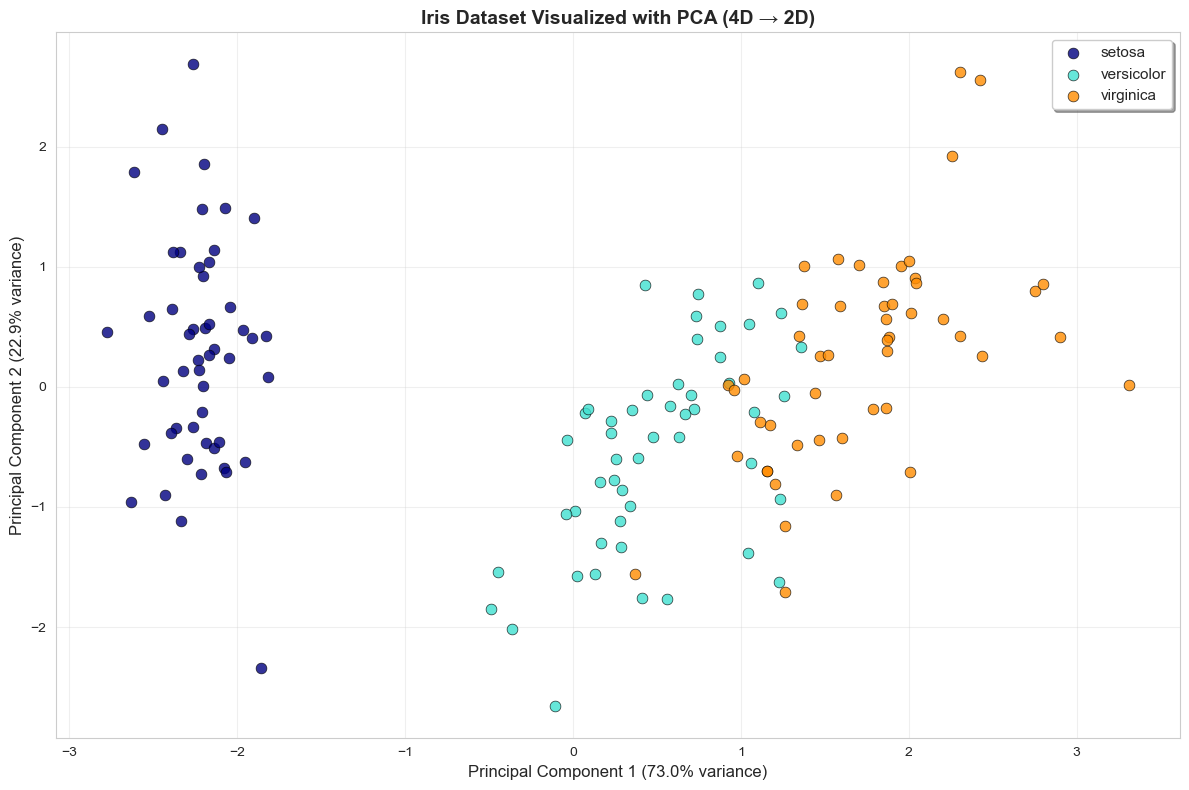


✓ We can now see all 4 dimensions in a single 2D plot!
✓ The three species are clearly separated.
✓ This would have been impossible without PCA.


In [22]:
# Create a beautiful 2D visualization
plt.figure(figsize=(12, 8))

colors = ['navy', 'turquoise', 'darkorange']
for i, (color, target_name) in enumerate(zip(colors, target_names)):
    plt.scatter(
        X_pca[y == i, 0],  # PC1
        X_pca[y == i, 1],  # PC2
        color=color,
        alpha=0.8,
        s=60,
        label=target_name,
        edgecolors='black',
        linewidth=0.5
    )

plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.1%} variance)', 
           fontsize=12)
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.1%} variance)', 
           fontsize=12)
plt.title('Iris Dataset Visualized with PCA (4D → 2D)', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=11, shadow=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ We can now see all 4 dimensions in a single 2D plot!")
print("✓ The three species are clearly separated.")
print("✓ This would have been impossible without PCA.")

---

## Part 3: How Many Components Should We Keep?

**Question:** Should we keep 1 component? 2? All 4?

### The Scree Plot

A **scree plot** shows how much variance each component explains. Look for an "elbow" where the curve flattens.

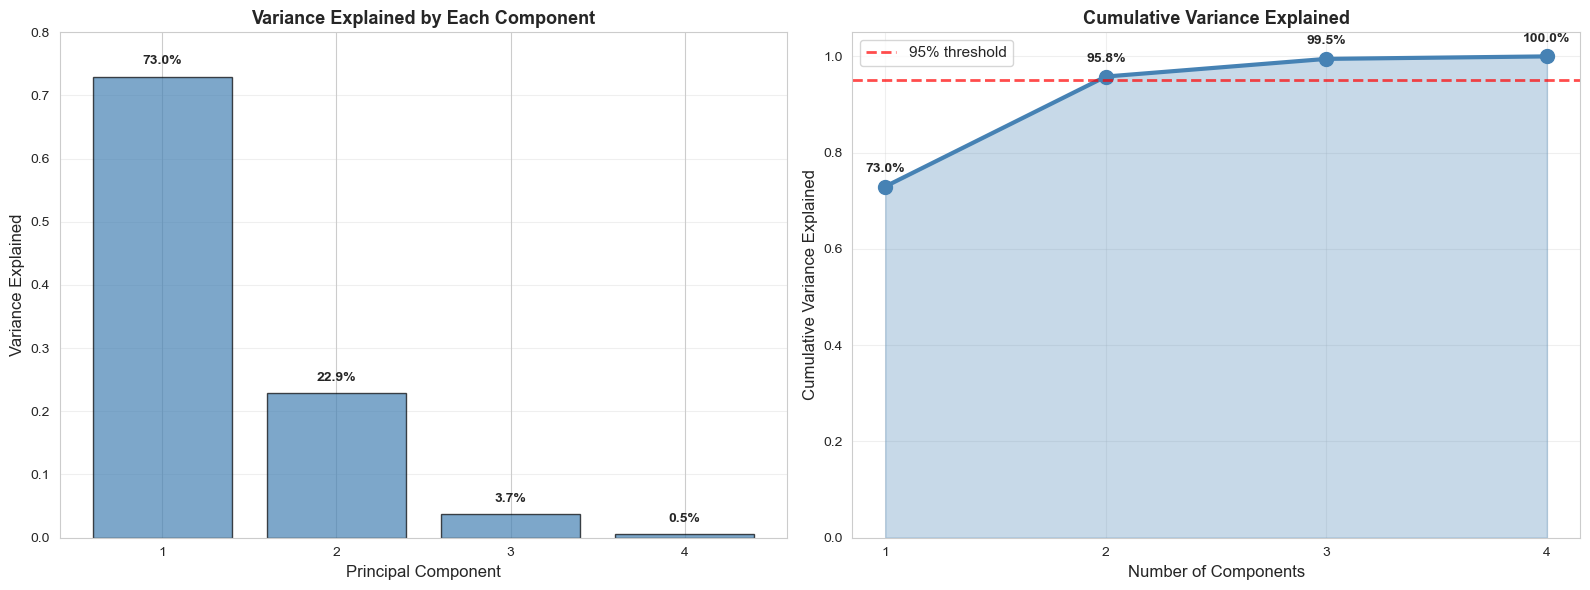


Variance Analysis:
PC1:  73.0% (cumulative:  73.0%)
PC2:  22.9% (cumulative:  95.8%)
PC3:   3.7% (cumulative:  99.5%)
PC4:   0.5% (cumulative: 100.0%)

📊 Interpretation:
  • PC1 alone captures 73.0% of variance
  • PC1 + PC2 capture 95.8% of variance
  • 2 components are enough to keep >95% of information!


In [23]:
# Fit PCA with all components
pca_full = PCA(n_components=4)
pca_full.fit(X_scaled)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Individual variance
axes[0].bar(range(1, 5), pca_full.explained_variance_ratio_, 
            alpha=0.7, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Principal Component', fontsize=12)
axes[0].set_ylabel('Variance Explained', fontsize=12)
axes[0].set_title('Variance Explained by Each Component', fontsize=13, fontweight='bold')
axes[0].set_xticks(range(1, 5))
axes[0].set_ylim([0, 0.8])
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(pca_full.explained_variance_ratio_):
    axes[0].text(i+1, v+0.02, f'{v:.1%}', ha='center', fontweight='bold')

# Plot 2: Cumulative variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
axes[1].plot(range(1, 5), cumulative_variance, 'o-', 
             linewidth=3, markersize=10, color='steelblue')
axes[1].axhline(y=0.95, color='red', linestyle='--', linewidth=2, 
                alpha=0.7, label='95% threshold')
axes[1].fill_between(range(1, 5), cumulative_variance, alpha=0.3, color='steelblue')
axes[1].set_xlabel('Number of Components', fontsize=12)
axes[1].set_ylabel('Cumulative Variance Explained', fontsize=12)
axes[1].set_title('Cumulative Variance Explained', fontsize=13, fontweight='bold')
axes[1].set_xticks(range(1, 5))
axes[1].set_ylim([0, 1.05])
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

# Add value labels
for i, v in enumerate(cumulative_variance):
    axes[1].text(i+1, v+0.03, f'{v:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Print analysis
print("\nVariance Analysis:")
print("=" * 50)
for i, (ind, cum) in enumerate(zip(pca_full.explained_variance_ratio_, cumulative_variance)):
    print(f"PC{i+1}: {ind:6.1%} (cumulative: {cum:6.1%})")

print("\n📊 Interpretation:")
print(f"  • PC1 alone captures {pca_full.explained_variance_ratio_[0]:.1%} of variance")
print(f"  • PC1 + PC2 capture {cumulative_variance[1]:.1%} of variance")
print(f"  • 2 components are enough to keep >95% of information!")

### Rule of Thumb

**Common strategies for choosing the number of components:**

1. **95% variance rule**: Keep enough components to explain 95% of variance
2. **Elbow method**: Look for the "elbow" where adding more components doesn't help much
3. **Fixed number**: Use 2-3 components for visualization, regardless of variance
4. **Cross-validation**: Test different numbers and see which gives best model performance

For Iris: **2 components** is perfect (97.8% variance + easy to visualize)

---

## Part 4: Practical Exercise - Wine Dataset

Let's apply PCA to a more challenging dataset: **Wine** with **13 features**!

### Exercise: Reduce 13D Wine Data to 2D

**Task:** Apply PCA to visualize the wine dataset.

**Steps:**
1. Load the wine dataset
2. Standardize the features
3. Apply PCA to reduce to 2 components
4. Create a scree plot
5. Visualize the 2D projection

**Hints:**
- Use `load_wine(as_frame=True)` to load data
- Follow the same steps as the Iris example
- The wine dataset has 3 classes (wine types)

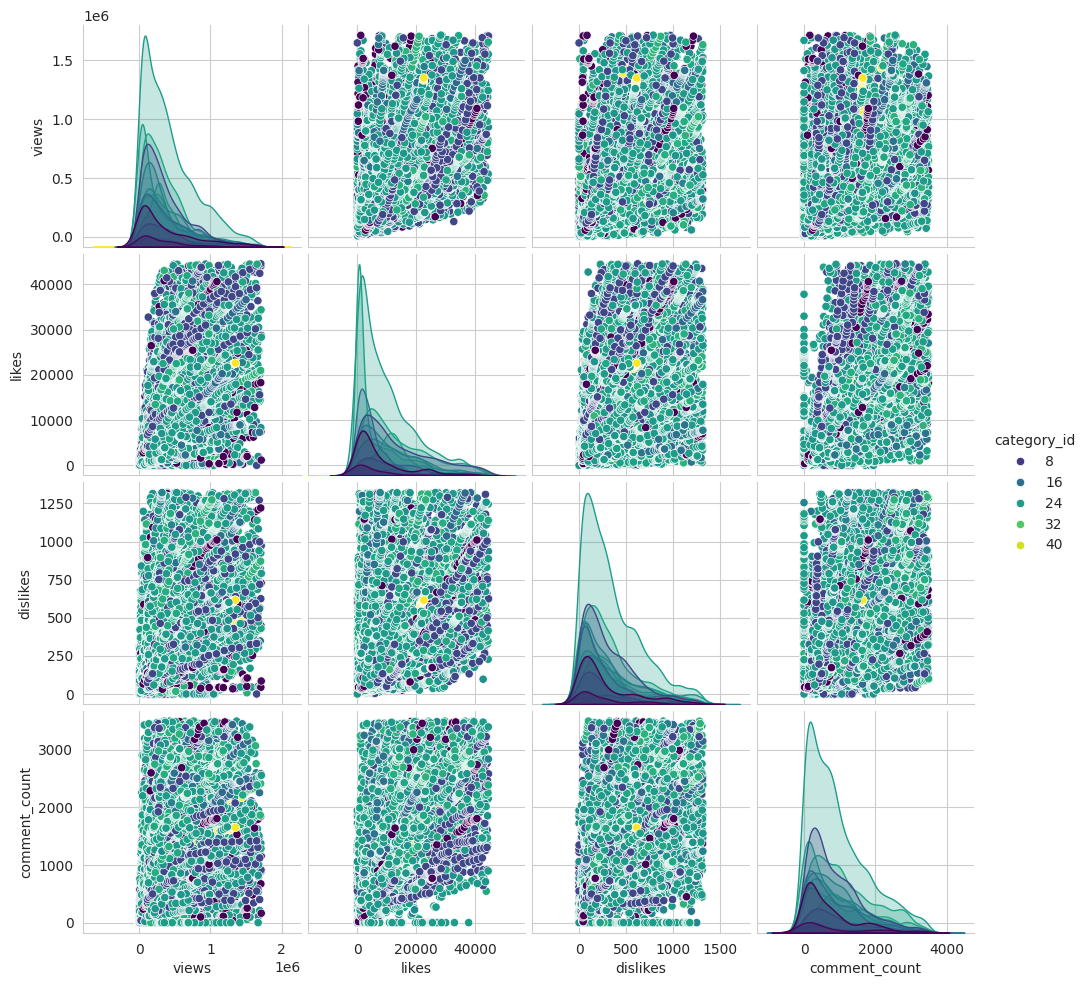

In [33]:
# Define features to clean
features = ['views', 'likes', 'dislikes', 'comment_count']

# Calculate IQR and filter outliers
for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Define bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Filter the DataFrame
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

# Now run your pairplot with the cleaned 'df'
sns.pairplot(df[features + ['category_id']], hue='category_id', palette='viridis')


In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Step 1: Standardize
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

# Step 2: PCA to 2D
pca = PCA(n_components=2)
pca_results = pca.fit_transform(scaled_data)

# Create a DataFrame for plotting
pca_df = pd.DataFrame(data=pca_results, columns=['PC1', 'PC2'])
pca_df['views'] = df['views'] # Keep original dimensions for coloring
pca_df['category_id'] = df['category_id']

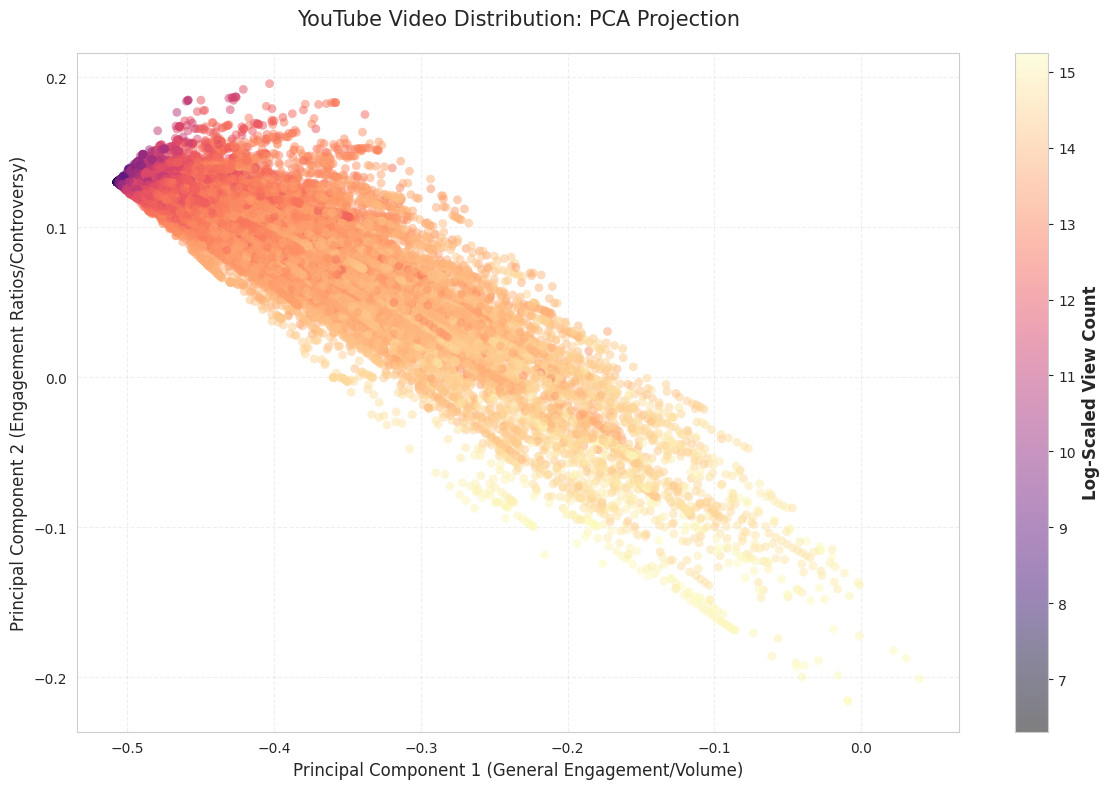

In [46]:
import matplotlib.ticker as ticker

plt.figure(figsize=(12, 8))

# Use a more distinct colormap and adjust alpha for density visibility
scatter = plt.scatter(pca_df['PC1'], pca_df['PC2'], 
            c=np.log1p(pca_df['views']), 
            cmap='magma', alpha=0.5, s=40, edgecolors='none')

# Create a colorbar with human-readable labels
cbar = plt.colorbar(scatter)
cbar.set_label('Log-Scaled View Count', fontsize=12, fontweight='bold')

# Customizing the axes
plt.xlabel('Principal Component 1 (General Engagement/Volume)', fontsize=12)
plt.ylabel('Principal Component 2 (Engagement Ratios/Controversy)', fontsize=12)
plt.title('YouTube Video Distribution: PCA Projection', fontsize=15, pad=20)

plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

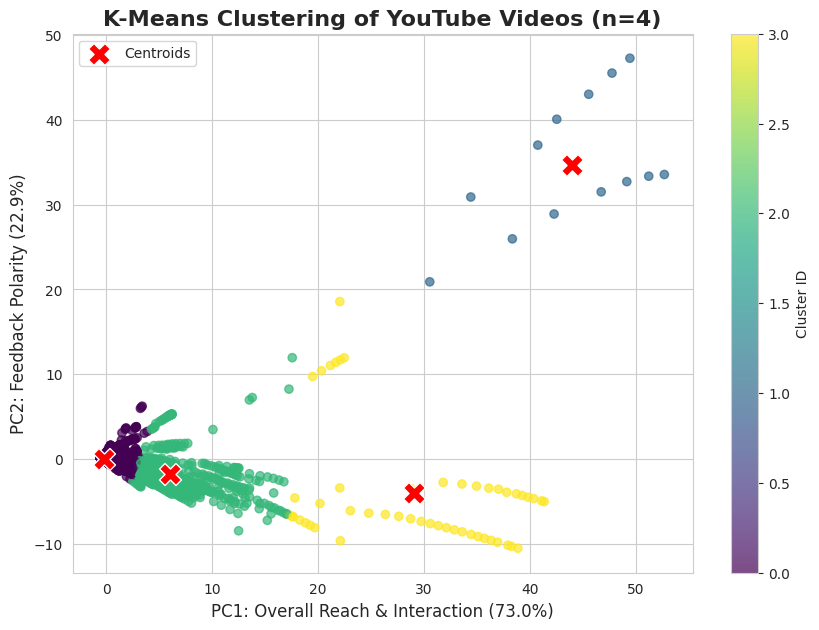

In [50]:
from sklearn.cluster import KMeans

# 1. Initialize KMeans (3 is ideal for Iris since there are 3 species)
n_clusters = 4 
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)

# 2. FIT the model to your PCA results
# This "teaches" kmeans where the centers are
kmeans.fit(pca_results) 

# 3. Assign the cluster labels
pca_df['cluster'] = kmeans.labels_

# 4. Plot the results
plt.figure(figsize=(10, 7))
# Plot the data points colored by cluster
scatter = plt.scatter(pca_df['PC1'], pca_df['PC2'], 
            c=pca_df['cluster'], 
            cmap='viridis', alpha=0.7)

# Plot the centroids
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], 
            marker='X', s=250, c='red', edgecolors='white', label='Centroids')

plt.colorbar(scatter, label='Cluster ID')
plt.xlabel('PC1: Overall Reach & Interaction (73.0%)', fontsize=12)
plt.ylabel('PC2: Feedback Polarity (22.9%)', fontsize=12)
plt.title('K-Means Clustering of YouTube Videos (n=4)', fontsize=16, fontweight='bold')

plt.legend()
plt.show()

In [ ]:
# TODO: Visualize 2D projection with wine classes
plt.figure(figsize=(12, 8))
# Your visualization code here
# Hint: Use different colors for each wine class (0, 1, 2)
plt.show()

---

## Part 5: Exercise - PCA + K-Means on Wine Data

In the previous exercise you used PCA to visualize the wine dataset. Now let's combine PCA with **K-Means clustering** (from the clustering notebook) to see how dimensionality reduction can improve clustering results.

**Goal:** Apply PCA to reduce the 13 wine features to 2 dimensions, then run K-Means on the reduced data and visualize the clusters.

**Why combine PCA with K-Means?**
- K-Means can struggle with high-dimensional data (the "curse of dimensionality")
- PCA removes noise and correlated features, giving K-Means cleaner data to work with
- With 2 components we can easily visualize the cluster assignments

**Steps:**
1. Load and standardize the wine data
2. Apply PCA to reduce to 2 components
3. Run K-Means (k=3) on the PCA-transformed data
4. Visualize the clusters and compare to the true wine classes

### Task 1: Standardize and apply PCA

Reuse the wine data loaded above. Standardize it and apply PCA with 2 components.

**Hints:**
- `StandardScaler().fit_transform(X_wine)`
- `PCA(n_components=2).fit_transform(...)`

In [ ]:
from sklearn.cluster import KMeans

# TODO: Standardize the wine data
scaler_km = StandardScaler()
X_wine_scaled_km = None  # Use scaler_km.fit_transform(X_wine)

# TODO: Apply PCA with 2 components
pca_km = None  # Create PCA(n_components=2)
X_wine_pca_km = None  # Use pca_km.fit_transform(...)

print(f"Original shape: {X_wine.shape}")
print(f"After PCA: {X_wine_pca_km.shape}")
print(f"Variance explained: {pca_km.explained_variance_ratio_}")
print(f"Total variance preserved: {pca_km.explained_variance_ratio_.sum():.1%}")

### Task 2: Run K-Means on the PCA-reduced data

Apply K-Means with k=3 clusters to the PCA-transformed data.

**Hints:**
- `KMeans(n_clusters=3, random_state=42, n_init=10)`
- Use `.fit_predict(X_wine_pca_km)` to get cluster labels

In [ ]:
# TODO: Run K-Means with 3 clusters on the PCA-transformed data
kmeans = None  # Create KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = None  # Use kmeans.fit_predict(X_wine_pca_km)

print(f"Cluster labels: {np.unique(clusters)}")
print(f"Samples per cluster: {[np.sum(clusters == i) for i in range(3)]}")

### Task 3: Visualize clusters vs. true labels

Create two side-by-side scatter plots of the PCA-reduced data:
1. **Left plot:** Color points by K-Means cluster assignment
2. **Right plot:** Color points by the true wine class (`y_wine`)

Also plot the cluster centroids on the left plot.

**Hints:**
- Use `plt.subplots(1, 2, figsize=(16, 6))`
- Use `axes[0].scatter(...)` and `axes[1].scatter(...)`
- Centroids are at `kmeans.cluster_centers_`
- Compare: do the K-Means clusters match the true classes?

In [ ]:
# TODO: Create side-by-side plots comparing K-Means clusters to true labels
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: K-Means clusters
# axes[0].scatter(X_wine_pca_km[:, 0], X_wine_pca_km[:, 1], c=clusters, cmap='viridis', ...)
# Don't forget to plot the centroids!
# axes[0].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], ...)

# Right plot: True wine classes
# axes[1].scatter(X_wine_pca_km[:, 0], X_wine_pca_km[:, 1], c=y_wine, cmap='viridis', ...)

# Add labels, titles, and colorbars
# axes[0].set_title('K-Means Clusters (k=3)')
# axes[1].set_title('True Wine Classes')

plt.tight_layout()
plt.show()

### Bonus: Compare K-Means on original data vs. PCA-reduced data

Does PCA actually help K-Means? Run K-Means on the **original 13 features** (standardized, without PCA) and compare the results to PCA + K-Means.

**Hint:** Use `sklearn.metrics.adjusted_rand_score(y_wine, clusters)` to measure how well the clusters match the true labels. A score of 1.0 means perfect match.

In [ ]:
from sklearn.metrics import adjusted_rand_score

# TODO: Run K-Means on original standardized data (without PCA)
kmeans_original = None  # KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_original = None  # kmeans_original.fit_predict(X_wine_scaled_km)

# TODO: Compare using adjusted_rand_score
ari_pca = None  # adjusted_rand_score(y_wine, clusters)
ari_original = None  # adjusted_rand_score(y_wine, clusters_original)

print("Adjusted Rand Index (higher = better match to true labels):")
print(f"  K-Means on original 13 features: {ari_original:.3f}")
print(f"  K-Means on PCA 2 components:     {ari_pca:.3f}")

---

## Bonus: PCA in a Supervised Machine Learning Pipeline (Spoilers for Day 3)

PCA is often used as a **preprocessing step** before machine learning.

### Why use PCA before ML?

1. **Faster training** - Fewer features = faster algorithms
2. **Less overfitting** - Removing noisy dimensions helps generalization
3. **Handle multicollinearity** - Removes correlated features

### Example: Classification Pipeline

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_wine, y_wine, test_size=0.3, random_state=42
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

# Approach 1: Without PCA
print("\n=== Without PCA (13 features) ===")
scaler1 = StandardScaler()
X_train_scaled = scaler1.fit_transform(X_train)
X_test_scaled = scaler1.transform(X_test)

knn1 = KNeighborsClassifier(n_neighbors=5)
knn1.fit(X_train_scaled, y_train)
y_pred1 = knn1.predict(X_test_scaled)

acc1 = accuracy_score(y_test, y_pred1)
print(f"Accuracy: {acc1:.1%}")

# Approach 2: With PCA
print("\n=== With PCA (2 components) ===")
scaler2 = StandardScaler()
X_train_scaled2 = scaler2.fit_transform(X_train)
X_test_scaled2 = scaler2.transform(X_test)

pca2 = PCA(n_components=2)
X_train_pca = pca2.fit_transform(X_train_scaled2)
X_test_pca = pca2.transform(X_test_scaled2)

knn2 = KNeighborsClassifier(n_neighbors=5)
knn2.fit(X_train_pca, y_train)
y_pred2 = knn2.predict(X_test_pca)

acc2 = accuracy_score(y_test, y_pred2)
print(f"Accuracy: {acc2:.1%}")
print(f"Variance kept: {pca2.explained_variance_ratio_.sum():.1%}")

print("\n📊 Comparison:")
print(f"  Features reduced: 13 → 2 (85% reduction)")
print(f"  Accuracy change: {acc1:.1%} → {acc2:.1%}")
print(f"  Training speed: Much faster with 2 features!")

Training set size: (124, 13)
Test set size: (54, 13)

=== Without PCA (13 features) ===
Accuracy: 96.3%

=== With PCA (2 components) ===
Accuracy: 98.1%
Variance kept: 55.0%

📊 Comparison:
  Features reduced: 13 → 2 (85% reduction)
  Accuracy change: 96.3% → 98.1%
  Training speed: Much faster with 2 features!


### Important Notes:

**✓ DO:**
- Fit PCA on training data only
- Transform both training and test data using the same PCA
- Always standardize before PCA

**✗ DON'T:**
- Fit PCA on test data (data leakage!)
- Skip standardization
- Apply PCA to categorical variables

---

## Part 7: When PCA Works Well vs. Poorly

### PCA Works Great When:

**1. Features are correlated**

In [52]:
# Example: Highly correlated features
np.random.seed(42)
x1 = np.random.randn(100)
x2 = x1 + np.random.randn(100) * 0.1  # x2 ≈ x1 (highly correlated)
X_corr = np.column_stack([x1, x2])

# Apply PCA
pca_corr = PCA(n_components=2)
X_corr_pca = pca_corr.fit_transform(X_corr)

print("Correlated features:")
print(f"  PC1 explains: {pca_corr.explained_variance_ratio_[0]:.1%}")
print(f"  PC2 explains: {pca_corr.explained_variance_ratio_[1]:.1%}")
print("\n→ PC1 captures almost all information!")
print("  We can reduce 2D → 1D with minimal loss.")

Correlated features:
  PC1 explains: 99.7%
  PC2 explains: 0.3%

→ PC1 captures almost all information!
  We can reduce 2D → 1D with minimal loss.


**2. Data has linear structure**

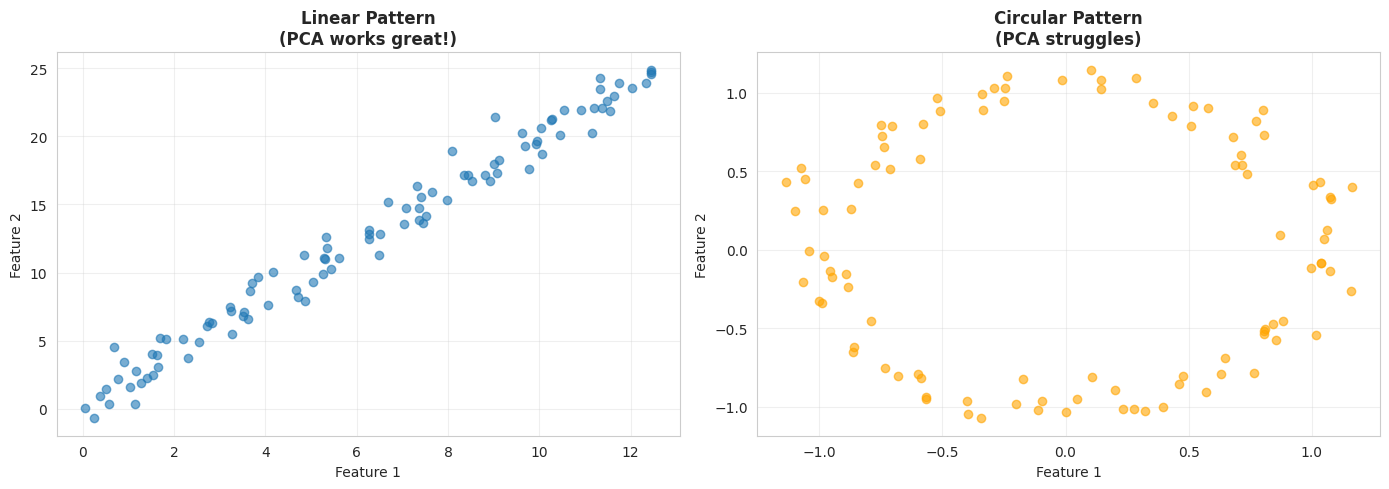


📌 Key insight:
  • PCA finds LINEAR patterns
  • For circular/spiral/complex patterns, use t-SNE or UMAP


In [53]:
# Visualize: Linear vs Non-linear data
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear structure (PCA works well)
np.random.seed(42)
t = np.linspace(0, 4*np.pi, 100)
x_linear = t + np.random.randn(100) * 0.5
y_linear = 2*t + np.random.randn(100) * 0.5
axes[0].scatter(x_linear, y_linear, alpha=0.6)
axes[0].set_title('Linear Pattern\n(PCA works great!)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')
axes[0].grid(True, alpha=0.3)

# Non-linear structure (PCA struggles)
t = np.linspace(0, 4*np.pi, 100)
x_circle = np.cos(t) + np.random.randn(100) * 0.1
y_circle = np.sin(t) + np.random.randn(100) * 0.1
axes[1].scatter(x_circle, y_circle, alpha=0.6, color='orange')
axes[1].set_title('Circular Pattern\n(PCA struggles)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📌 Key insight:")
print("  • PCA finds LINEAR patterns")
print("  • For circular/spiral/complex patterns, use t-SNE or UMAP")

### Summary: PCA Best Practices

| Do ✓ | Don't ✗ |
|------|----------|
| Standardize features first | Skip StandardScaler |
| Use scree plot to choose components | Arbitrarily pick a number |
| Fit on training data only | Fit on test data |
| Check variance explained | Assume you kept enough info |
| Use for visualization & speed | Use when you need interpretable features |
| Apply to numerical data | Apply to categorical data |

---

## Summary

Congratulations! You've learned:

✓ What dimensionality reduction is and why it's useful  
✓ How PCA works conceptually (without complex math)  
✓ How to apply PCA using sklearn  
✓ How to choose the number of components  
✓ How to visualize high-dimensional data in 2D  
✓ How to use PCA in a machine learning pipeline  
✓ When PCA works well vs. poorly  

### Key Takeaways:

1. **PCA reduces dimensions while keeping important patterns**
2. **Always standardize your data first** (`StandardScaler`)
3. **Use scree plots to choose components** (aim for 95% variance)
4. **PCA is great for visualization** (reduce to 2D or 3D)
5. **PCA can speed up machine learning** (fewer features)
6. **PCA assumes linear patterns** (use t-SNE/UMAP for complex data)

### What's Next?

- **Practice:** Apply PCA to your own datasets
- **Explore:** Try t-SNE or UMAP for non-linear patterns
- **Advanced:** Check out `demos/advanced/` for mathematical implementation
- **Combine:** Use PCA with clustering, classification, or regression

### Additional Resources:

- [Scikit-learn PCA Guide](https://scikit-learn.org/stable/modules/decomposition.html#pca)
- [StatQuest: PCA Explained Simply](https://www.youtube.com/watch?v=FgakZw6K1QQ)
- [Interactive PCA Visualization](http://setosa.io/ev/principal-component-analysis/)
- [When to use PCA vs t-SNE](https://towardsdatascience.com/pca-vs-t-sne-8ba043f5759)

---

**Want to learn the math behind PCA?** Check out the advanced notebook: `demos/advanced/05_Dimensionality_Reduction_Advanced.ipynb`